In [1]:
import yfinance as yf
from sklearn.model_selection import train_test_split
from skfolio.optimization import MeanRisk, ObjectiveFunction, MaximumDiversification, HierarchicalRiskParity, EqualWeighted, SchurComplementary, HierarchicalEqualRiskContribution
from skfolio.distance import DistanceCorrelation, MutualInformation
from skfolio.preprocessing import prices_to_returns
from skfolio import PerfMeasure, RiskMeasure, RatioMeasure, Population

## TODO
`yf.Ticker('0P00008YCS.F').funds_data.sector_weightings` gives us access to the exact allocation within a fund. We can reuse this downstream to set sector-wise constraints in our optimization procedure
For instance `Schroder ISF Glb Clmt Chg Eq A Acc EUR` actually contains 28% of Technology stocks, most of them US-based
`yf.Ticker('0P00008YCS.F').funds_data.asset_classes` yields the inner securities subtypes


In [2]:
# (fund name as in the source table, ISIN)
assets = { # original universe from private banker
    "MSIF Global Convertible Bonds EUR": "LU0149084633",
    "BGF European High Yield Bond A2": "LU1191877379",
    "CD Alpha Bonds C": "FR0010249664",
    "Butler Credit Opportunities": "IE00BMVX2J49",
    "Lazard Patrimoine Opportunitie SRI": "FR0007028543",
    "CMAM Flexible Euro RC": "FR0013384336",
    "Madeleine Opportunities": "LU0961755823",  # low ESG grade but might allow for diversification over higher ESG-scorers
    "GS Europe CORE Equity Base Acc EUR": "LU0234682044", # this should be LU0234681749 but yfinance fails to source it. LU0234682044 has different fee structure but similar performance. We use it as a proxy
    "CMAM Convictions Euro RC": "FR0013384963",
    #"JPMF Euroland Equity A Acc EUR": "LU0210529490",
    #"UBS European Equity Value Opp P EUR": "LU0153925689",
    #"Sycomore Sélection Responsable R": "FR0011169341",  # LOW_IMPACT
    #"Goldman Sachs Eurozone Equity Income RC C EUR": "LU0127786431",
    #"CD Euro Capital": "FR0010250084",
    "Mirova Euro Sustainable Equity": "LU0914731947",
    #"CD France Expertise": "FR0010249672",
    "Madeleine Mid Caps Euro": "LU1044932975",
    "Lazard Equity SRI RC EUR": "FR0013204187",
    #"Indépendance Europe Small": "LU1832174962",
    #"T. Rowe Price US Smlr Cm Eq A EUR": "LU0918140210",
    #"Robeco QI EM Active Equities": "LU0329355670",
    #"M&G Lux Global Emerg Mkt Fd A EUR Acc": "LU1670618690",
    #"Nordea 1 - Emerging Stars Equity BP EUR": "LU0602539867",
    #"Ofi Invest Actions Japon": "FR0013392065",
    "RobecoSAM Smart Energy B EUR Acc": "LU2145461757",
    #"Fidelity Global Technology A-Acc-EUR": "LU1213836080",
    "BlackRock World Gold Fund": "LU0171305526", 
    "RobecoSAM Sustainable Water B EUR": "LU2146190835",
    #"M&G Episode Macro": "LU1670714226",
    #"BDL Rempart C": "FR0010174144",
    #"BGF World Healthscience A2": "LU0171307068",
    #"Eleva UCITS Eleva Abs Ret Eurp Eq A acc": "LU1920211973",
    "Schroder ISF Glb Clmt Chg Eq A Acc EUR": "LU0302446645",
    #"SLF LUX Eq Env & Biodiv Imp EUR R Acc": "LU2349917364",
    "Pictet Robotics P EUR Acc": "LU1279334210",
    "BDL transition": "LU1988108350",  # ISIN partially cut off in source image - verify
}

proxies = { # we sometimes use proxies since yfinance has limited history for our beloved UCITS
    "BlackRock World Gold Fund": "RING",
    "RobecoSAM Sustainable Water B EUR": "0P0001KWKR.F",
    "Pictet Robotics P EUR Acc": "BOTZ",
    "Schroder ISF Glb Clmt Chg Eq A Acc EUR": "0P00008YCS.F",
    "RobecoSAM Smart Energy B EUR Acc": "0P0001KWJF.F",
}
assert set(proxies).issubset(assets)
{**assets, **proxies}


{'MSIF Global Convertible Bonds EUR': 'LU0149084633',
 'BGF European High Yield Bond A2': 'LU1191877379',
 'CD Alpha Bonds C': 'FR0010249664',
 'Butler Credit Opportunities': 'IE00BMVX2J49',
 'Lazard Patrimoine Opportunitie SRI': 'FR0007028543',
 'CMAM Flexible Euro RC': 'FR0013384336',
 'Madeleine Opportunities': 'LU0961755823',
 'GS Europe CORE Equity Base Acc EUR': 'LU0234682044',
 'CMAM Convictions Euro RC': 'FR0013384963',
 'Mirova Euro Sustainable Equity': 'LU0914731947',
 'Madeleine Mid Caps Euro': 'LU1044932975',
 'Lazard Equity SRI RC EUR': 'FR0013204187',
 'RobecoSAM Smart Energy B EUR Acc': '0P0001KWJF.F',
 'BlackRock World Gold Fund': 'RING',
 'RobecoSAM Sustainable Water B EUR': '0P0001KWKR.F',
 'Schroder ISF Glb Clmt Chg Eq A Acc EUR': '0P00008YCS.F',
 'Pictet Robotics P EUR Acc': 'BOTZ',
 'BDL transition': 'LU1988108350'}

In [3]:
rename = {v: k for k, v in {**assets, **proxies}.items()}
df = yf.download(list({**assets, **proxies}.values()), period='10y', interval='1d', multi_level_index=False).Close.rename(rename, axis=1)
returns = prices_to_returns(df, nan_threshold=0.6, drop_inceptions_nan=True, fill_nan=True).bfill()
assert not returns.isna().sum().sum() and len(df) > 0
print(returns.shape, returns.index.min(), returns.index.max(), '\n\n')
for col in returns.columns:
    print(col, returns[col].dropna().index.min())

[*********************100%***********************]  18 of 18 completed


(1076, 18) 2022-03-08 00:00:00 2026-06-24 00:00:00 


Schroder ISF Glb Clmt Chg Eq A Acc EUR 2022-03-08 00:00:00
RobecoSAM Smart Energy B EUR Acc 2022-03-08 00:00:00
RobecoSAM Sustainable Water B EUR 2022-03-08 00:00:00
Pictet Robotics P EUR Acc 2022-03-08 00:00:00
Lazard Patrimoine Opportunitie SRI 2022-03-08 00:00:00
CD Alpha Bonds C 2022-03-08 00:00:00
Lazard Equity SRI RC EUR 2022-03-08 00:00:00
CMAM Flexible Euro RC 2022-03-08 00:00:00
CMAM Convictions Euro RC 2022-03-08 00:00:00
Butler Credit Opportunities 2022-03-08 00:00:00
MSIF Global Convertible Bonds EUR 2022-03-08 00:00:00
GS Europe CORE Equity Base Acc EUR 2022-03-08 00:00:00
Mirova Euro Sustainable Equity 2022-03-08 00:00:00
Madeleine Opportunities 2022-03-08 00:00:00
Madeleine Mid Caps Euro 2022-03-08 00:00:00
BGF European High Yield Bond A2 2022-03-08 00:00:00
BDL transition 2022-03-08 00:00:00
BlackRock World Gold Fund 2022-03-08 00:00:00


<Axes: xlabel='Date'>

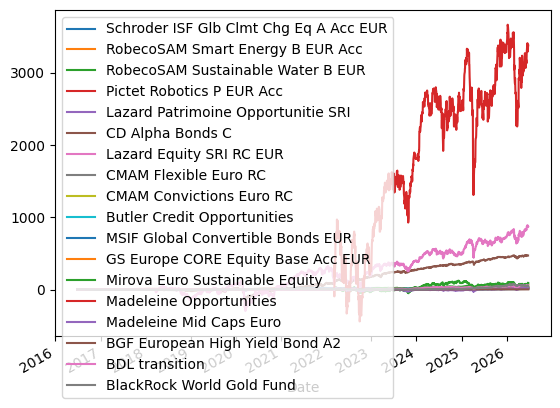

In [4]:
import polars as pl
import polars.selectors as cs
pl.from_pandas(df, include_index=True).with_columns(cs.numeric().backward_fill() - cs.numeric().backward_fill().first()).to_pandas().set_index('Date').plot()

In [5]:
#X = prices_to_returns(returns)
X_train, X_test = train_test_split(returns, test_size=0.3, shuffle=False)
groups = {k: 'Bond' for k in assets if 'bond' in k.lower() or 'credit' in k.lower()} # TODO 
groups.update({k: 'Sustainable' for k in assets if 'sustainable' in k.lower()})
print(groups)
print(X_train.index.max(), X_test.index.max())
kwargs = dict(
    solver="SCIP", 
    #min_weights=0.05,
    cardinality=6,
    linear_constraints=[
        "Sustainable >= 0.3", 
        "BlackRock World Gold Fund >= 0.1",
        "Bond + 0.4 * Lazard Patrimoine Opportunitie SRI + 0.15 * CMAM Flexible Euro RC <= 0.2", #Lazard Patrimoine Opportunitie SRI containe 40% of bonds ..
    ],
    #min_weights=0.05,
    max_weights=0.3,
    groups=groups,
    #risk_free_rate=0.0003,  # FIXME
    #management_fees=0.01,  # FIXME
)

pop = Population([])
models = dict()

for model in (
    MeanRisk(risk_measure=RiskMeasure.SEMI_DEVIATION, objective_function=ObjectiveFunction.MAXIMIZE_UTILITY, **kwargs), 
    MaximumDiversification(**kwargs),
    HierarchicalRiskParity(risk_measure=RiskMeasure.SEMI_DEVIATION, distance_estimator=DistanceCorrelation()),
    EqualWeighted(),  # THIS IS OUR BASELINE
    SchurComplementary(distance_estimator=DistanceCorrelation()),
    #HierarchicalEqualRiskContribution(distance_estimator=MutualInformation()),
    ):
    model.fit(X_train)
    pop.append(model.predict(X_test))
    models[type(model).__name__] = model


pop.plot_cumulative_returns()

{'MSIF Global Convertible Bonds EUR': 'Bond', 'BGF European High Yield Bond A2': 'Bond', 'CD Alpha Bonds C': 'Bond', 'Butler Credit Opportunities': 'Bond', 'Mirova Euro Sustainable Equity': 'Sustainable', 'RobecoSAM Sustainable Water B EUR': 'Sustainable'}
2025-03-05 00:00:00 2026-06-24 00:00:00


In [6]:
pop.rolling_measure(RiskMeasure.MAX_DRAWDOWN, window=30).max()

MeanRisk                  0.106252
MaximumDiversification    0.110684
HierarchicalRiskParity    0.069007
EqualWeighted             0.113615
SchurComplementary        0.028658
dtype: float64

In [7]:
pop.plot_rolling_measure(RiskMeasure.MAX_DRAWDOWN, window=30)

In [8]:
pop.plot_rolling_measure(RiskMeasure.SEMI_VARIANCE, window=30)

In [9]:
pop.summary().loc[[
    'Annualized Mean', 
    'Annualized Semi-Variance',
    'MAX Drawdown', 
    'Value at Risk at 95%',
    'Annualized Sortino Ratio', 
    'Calmar Ratio', 
    'Annualized Sharpe Ratio',
    'Effective Number of Assets',
    #'Ulcer Index',
    'Skew',
    'Kurtosis',
    'Drawdown at Risk Ratio at 95%',
    'Value at Risk Ratio at 95%',
    'CVaR Ratio at 95%',
]]

,MeanRisk,MaximumDiversification,HierarchicalRiskParity,EqualWeighted,SchurComplementary
Annualized Mean,13.15%,17.52%,8.77%,15.87%,3.19%
Annualized Semi-Variance,0.66%,0.85%,0.23%,0.71%,0.034%
MAX Drawdown,10.63%,11.07%,6.90%,11.36%,2.87%
Value at Risk at 95%,1.03%,1.18%,0.62%,1.01%,0.23%
Annualized Sortino Ratio,1.62,1.90,1.82,1.89,1.72
Calmar Ratio,0.0049,0.0063,0.0050,0.0055,0.0044
Annualized Sharpe Ratio,1.19,1.42,1.34,1.40,1.28
Effective Number of Assets,4.632165904771429,5.745307419306656,8.85147395159287,18.0,2.664813017226583
Skew,-40.66%,-62.27%,-51.67%,-59.14%,-56.16%
Kurtosis,639.31%,635.47%,801.19%,716.80%,1091.17%


In [10]:
import pandas as pd
final_portfolio = pop.summary().loc['Calmar Ratio'].idxmax() # we take the portfolio with the best Annualized Sortino Ratio. Calmar Ratio could also be chose
final_weights = pd.DataFrame({name: dict(zip(model.feature_names_in_, model.weights_)) for name, model in models.items()})[final_portfolio]
final_weights = final_weights.replace(0.0, None).dropna()
print(f"dropping {len(final_weights[final_weights <= 0.02])} elements")
final_weights = final_weights[final_weights > 0.02]
final_weights /= final_weights.sum()
final_weights

dropping 0 elements


Schroder ISF Glb Clmt Chg Eq A Acc EUR    0.198945
RobecoSAM Sustainable Water B EUR         0.202037
CMAM Flexible Euro RC                     0.176204
Mirova Euro Sustainable Equity            0.097963
BGF European High Yield Bond A2           0.173569
BlackRock World Gold Fund                 0.151282
Name: MaximumDiversification, dtype: object

In [13]:
import getpass
available_capital = int(getpass.getpass('Enter the amount of money you have'))
pd.Series(final_weights.values, index=final_weights.index.map(assets)) * available_capital

LU0302446645    1989.451768
LU2146190835    2020.369038
FR0013384336    1762.035869
LU0914731947     979.631866
LU1191877379    1735.694652
LU0171305526    1512.816806
dtype: object

In [12]:
import dcor
import itertools
pd.Series({f"{a} <-> {b}": dcor.distance_correlation(X_train[a], X_train[b]) for a, b in itertools.combinations(final_weights.index, 2)})

Schroder ISF Glb Clmt Chg Eq A Acc EUR <-> RobecoSAM Sustainable Water B EUR    0.340361
Schroder ISF Glb Clmt Chg Eq A Acc EUR <-> CMAM Flexible Euro RC                0.460167
Schroder ISF Glb Clmt Chg Eq A Acc EUR <-> Mirova Euro Sustainable Equity       0.511362
Schroder ISF Glb Clmt Chg Eq A Acc EUR <-> BGF European High Yield Bond A2      0.322996
Schroder ISF Glb Clmt Chg Eq A Acc EUR <-> BlackRock World Gold Fund            0.142046
RobecoSAM Sustainable Water B EUR <-> CMAM Flexible Euro RC                     0.443177
RobecoSAM Sustainable Water B EUR <-> Mirova Euro Sustainable Equity            0.517753
RobecoSAM Sustainable Water B EUR <-> BGF European High Yield Bond A2           0.148036
RobecoSAM Sustainable Water B EUR <-> BlackRock World Gold Fund                 0.244125
CMAM Flexible Euro RC <-> Mirova Euro Sustainable Equity                        0.794498
CMAM Flexible Euro RC <-> BGF European High Yield Bond A2                       0.223019
CMAM Flexible Euro RC